In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import matplotlib

font_path = 'C:/Windows/Fonts/gulim.ttc'
font = fm.FontProperties(fname=font_path).get_name()
matplotlib.rc("font",family=font)

In [6]:
df = pd.read_csv('../EDA/Merge/data/result data/Final DF.csv')

In [7]:
df

,Year,Nation,Eng_Nation,Wc_Rank,Wc_Point,Q_WR,Q_GR,F_Rank,F_Point,F_Rd,...,FS_6,FS_7,FS_8,FS_9,FS_10,FS_11,FS_12,FS_13,ATK_INDEX,DEF_INDEX
0,2002,브라질,Brazil,1,21,0.46,2.352113,1.33,818.33,0.00,...,67.95,75.27,77.05,72.73,82.09,31.95,68.95,59.61,0.141500,-0.070093
1,2002,독일,Germany,2,16,0.55,1.817073,8.67,718.33,0.00,...,63.29,66.38,67.86,72.57,80.57,37.60,62.88,63.29,0.031444,0.011481
2,2002,터키,Turkey,3,13,0.46,1.457627,33.00,593.33,0.00,...,62.65,66.45,69.80,67.05,74.05,30.85,65.18,56.78,-0.039941,0.015588
3,2002,대한민국,South Korea,4,11,0.48,2.216667,42.00,573.00,0.00,...,55.41,65.91,65.50,65.68,72.45,32.64,57.66,62.23,0.040250,0.133021
4,2002,스페인,Spain,5,11,0.65,3.227273,5.00,742.33,0.00,...,69.77,75.50,78.23,78.09,83.27,35.05,69.80,64.55,-0.105762,-0.099683
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,2022,덴마크,Denmark,28,1,0.61,2.446429,13.33,1611.83,-18.00,...,68.77,72.19,70.69,67.92,70.15,17.13,66.37,53.93,NaN,NaN
188,2022,세르비아,Serbia,29,1,0.48,1.536232,31.33,1492.66,-18.00,...,62.65,66.19,72.58,69.38,64.15,18.21,64.19,51.35,NaN,NaN
189,2022,웨일스,Wales,30,1,0.44,1.233333,21.00,1545.20,10.75,...,67.38,66.19,63.88,55.19,66.27,17.62,59.62,53.12,NaN,NaN
190,2022,캐나다,Canada,31,0,0.48,2.296875,66.33,1356.74,-34.00,...,66.48,66.48,69.76,60.36,65.60,16.50,56.82,43.71,NaN,NaN


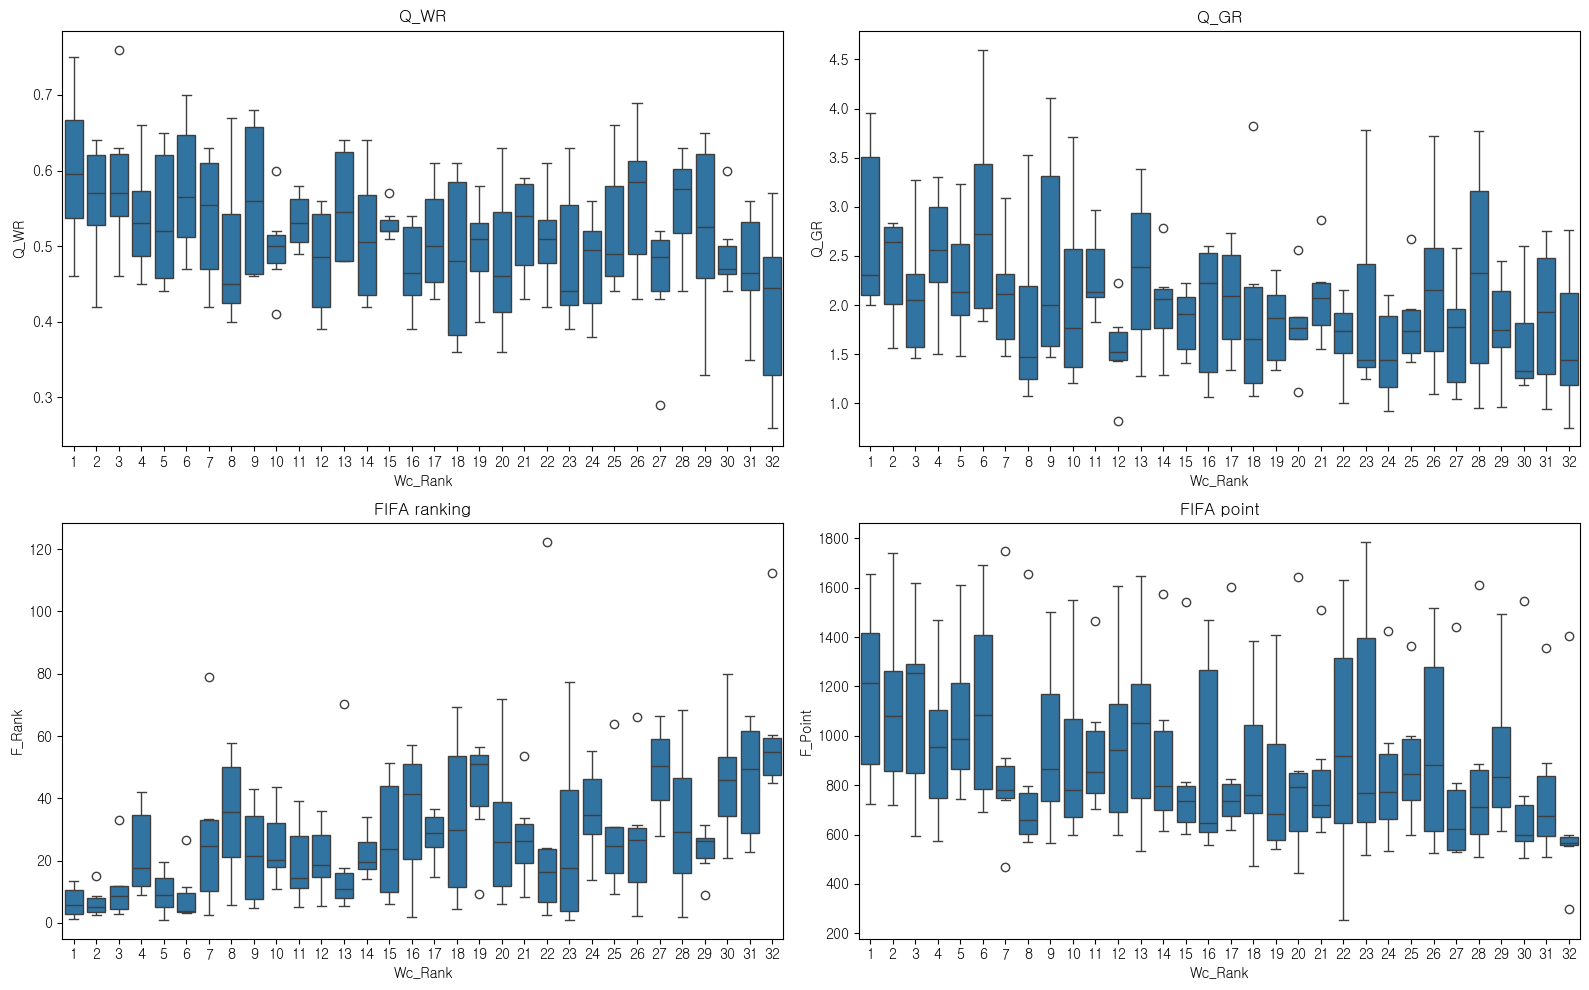

In [14]:
fig, ax = plt.subplots(2,2,figsize=(16,10))

sns.boxplot(x='Wc_Rank', y='Q_WR', data=df, ax=ax[0,0])
ax[0,0].set_title('Q_WR')

sns.boxplot(x='Wc_Rank', y='Q_GR', data=df, ax=ax[0,1])
ax[0,1].set_title('Q_GR')

sns.boxplot(x='Wc_Rank', y='F_Rank', data=df, ax=ax[1,0])
ax[1,0].set_title('FIFA ranking')

sns.boxplot(x='Wc_Rank', y='F_Point', data=df, ax=ax[1,1])
ax[1,1].set_title('FIFA point')

plt.tight_layout()
plt.show()

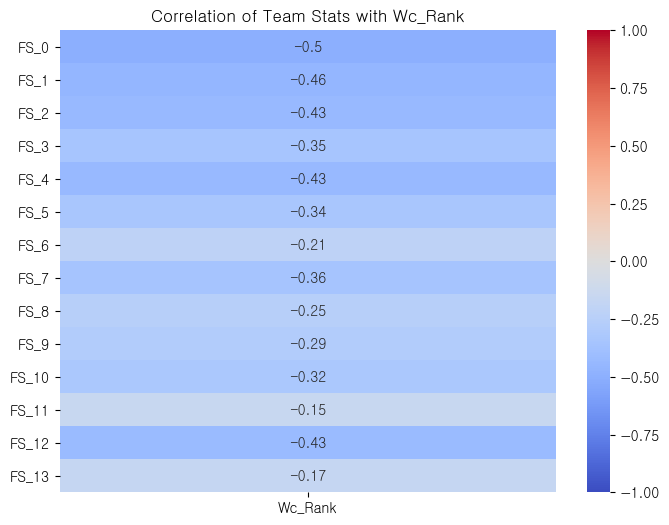

In [15]:
fs_cols = ['FS_0','FS_1','FS_2','FS_3','FS_4','FS_5','FS_6','FS_7','FS_8','FS_9','FS_10','FS_11','FS_12','FS_13']

# Wc_Rank와의 상관계수만 추출
corr_with_rank = df[fs_cols + ['Wc_Rank']].corr()['Wc_Rank'].drop('Wc_Rank')

plt.figure(figsize=(8,6))
sns.heatmap(corr_with_rank.to_frame(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Team Stats with Wc_Rank')
plt.show()


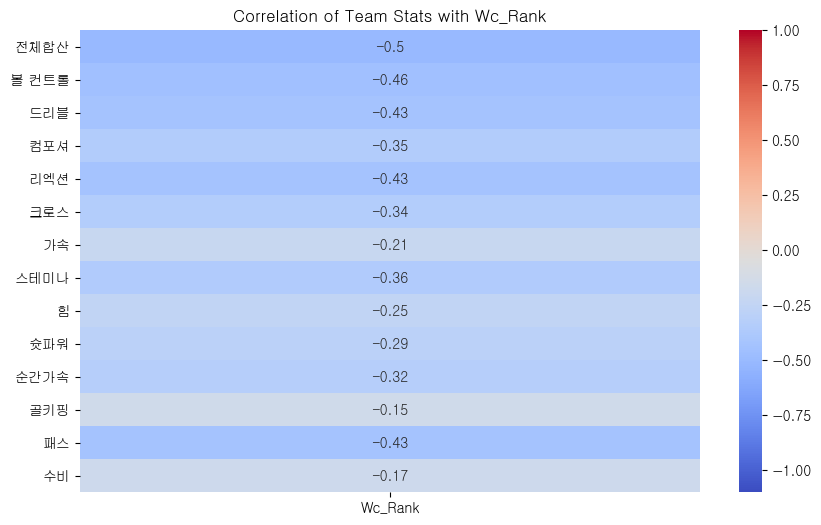

In [16]:
display_names = ['전체합산','볼 컨트롤','드리블','컴포셔','리엑션','크로스','가속','스테미나','힘','슛파워','순간가속','골키핑','패스','수비']
corr_with_rank = df[fs_cols + ['Wc_Rank']].corr()['Wc_Rank'].drop('Wc_Rank')

plt.figure(figsize=(10,6))
sns.heatmap(corr_with_rank.to_frame(), annot=True, cmap='coolwarm', vmin=1, vmax=-1,yticklabels=display_names)
plt.title('Correlation of Team Stats with Wc_Rank')
plt.show()

In [18]:
df.columns

Index(['Year', 'Nation', 'Eng_Nation', 'Wc_Rank', 'Wc_Point', 'Q_WR', 'Q_GR',
       'F_Rank', 'F_Point', 'F_Rd', 'F_Pd', 'Avg_Apps', 'Avg_Age',
       'Avg_Famous', 'FS_0', 'FS_1', 'FS_2', 'FS_3', 'FS_4', 'FS_5', 'FS_6',
       'FS_7', 'FS_8', 'FS_9', 'FS_10', 'FS_11', 'FS_12', 'FS_13', 'ATK_INDEX',
       'DEF_INDEX'],
      dtype='object')

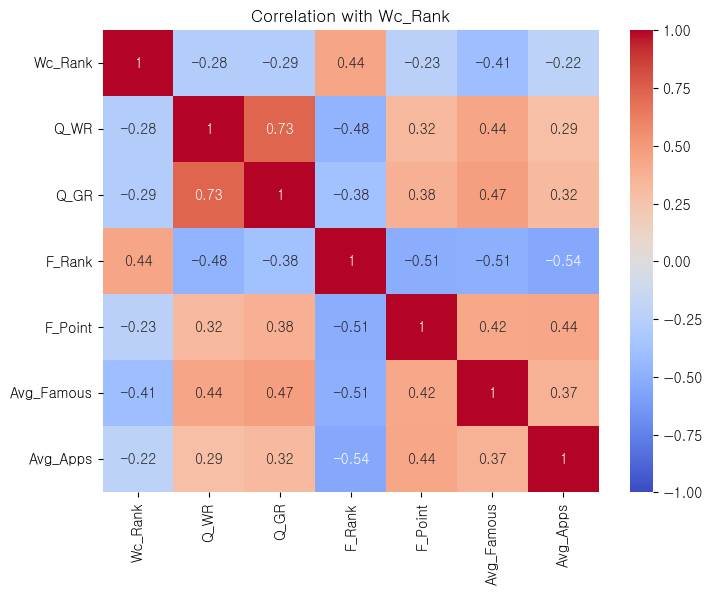

In [24]:
# 관심 있는 열만 선택
cols = ["Wc_Rank", "Q_WR", "Q_GR", "F_Rank", "F_Point", "Avg_Famous", "Avg_Apps"]

corr = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation with Wc_Rank")
plt.show()

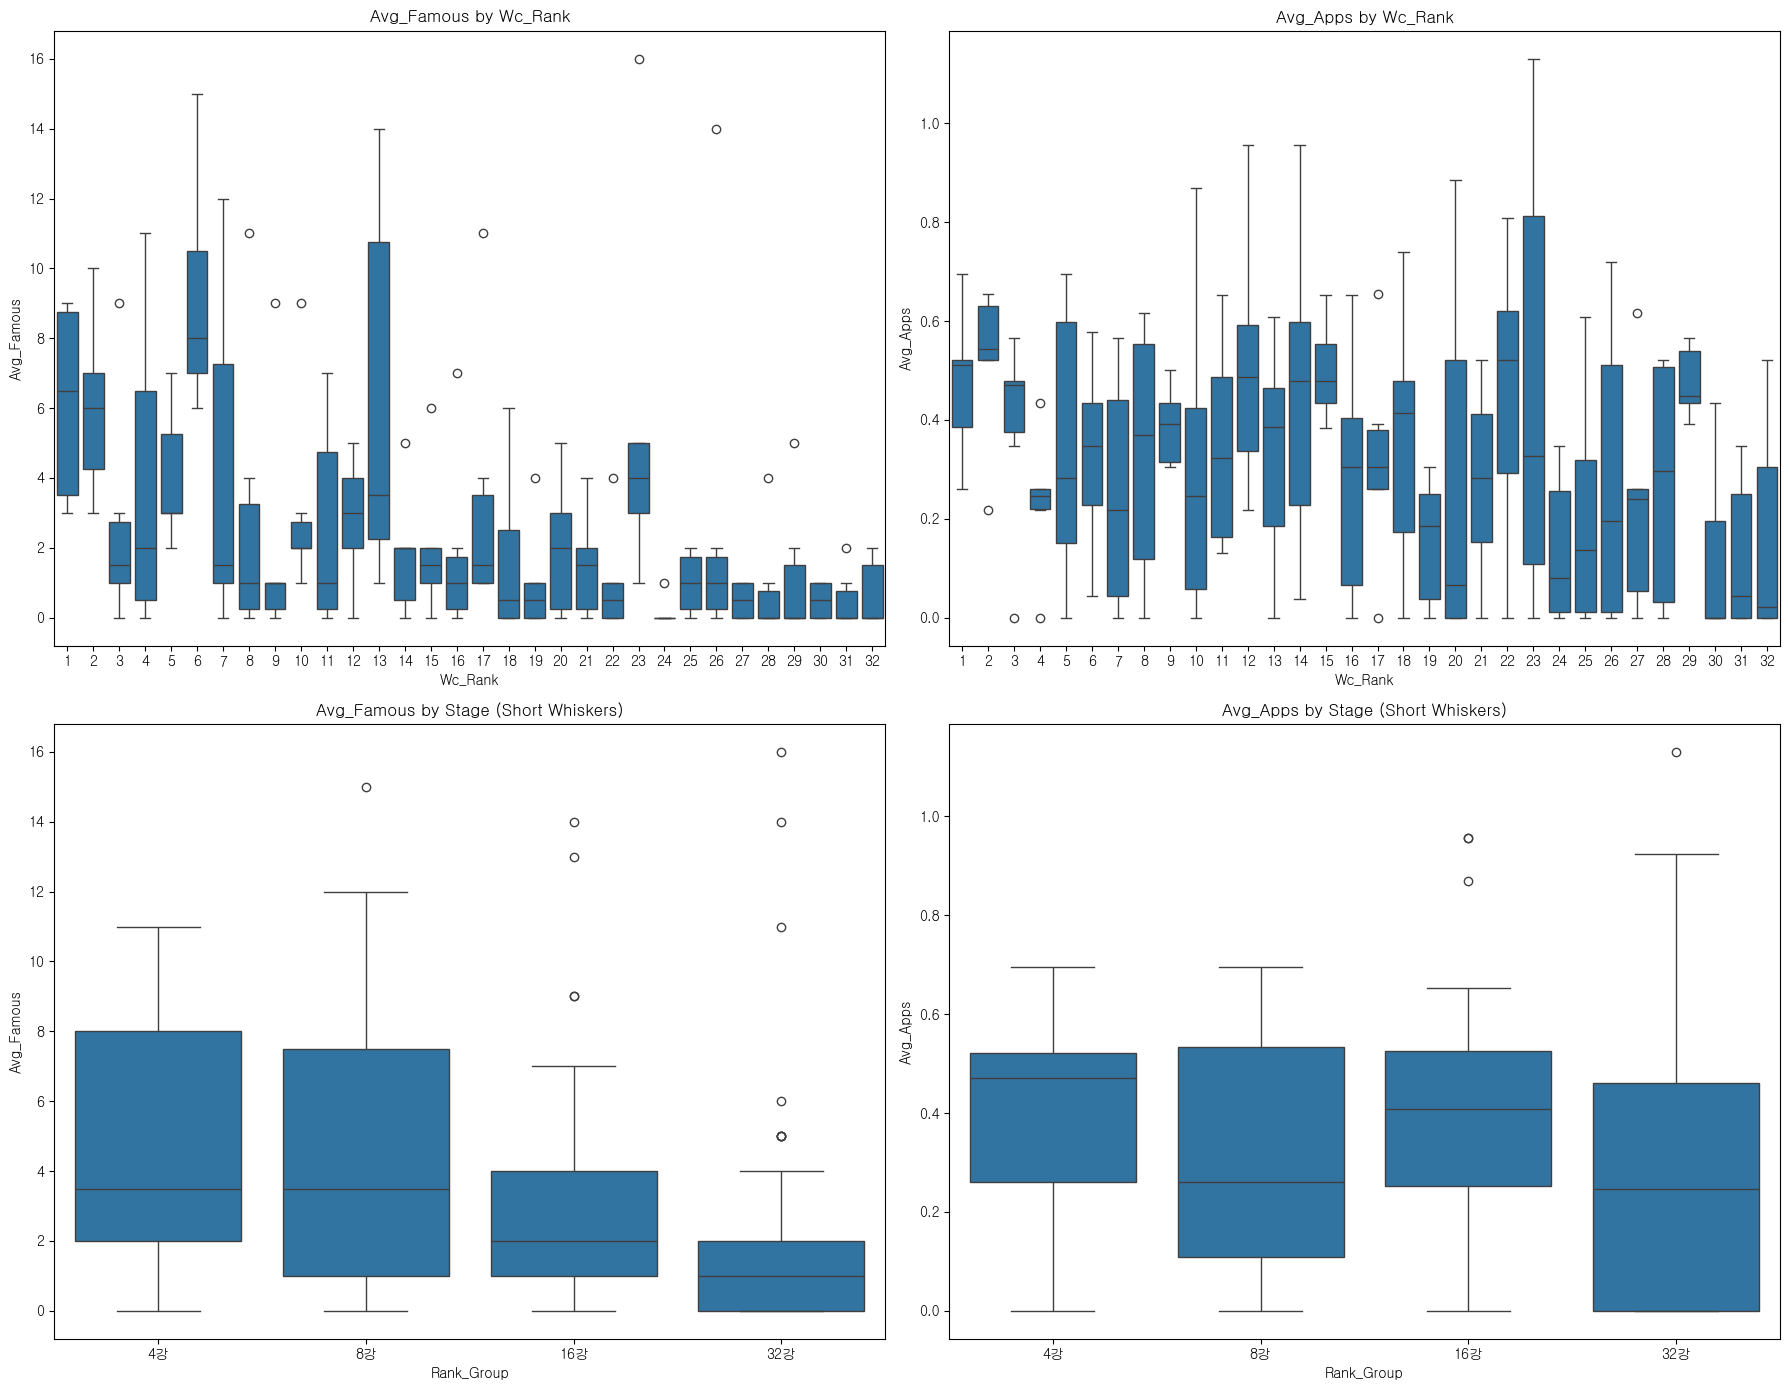

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 그룹핑 함수
def rank_stage(rank):
    if rank <= 4:
        return "4강"
    elif rank <= 8:
        return "8강"
    elif rank <= 16:
        return "16강"
    else:
        return "32강"

# 새로운 열 생성
df["Rank_Group"] = df["Wc_Rank"].apply(rank_stage)

fig, ax = plt.subplots(2, 2, figsize=(18, 14))

# === 위쪽: Wc_Rank 기준 ===
sns.boxplot(x="Wc_Rank", y="Avg_Famous", data=df, ax=ax[0,0])
ax[0,0].set_title("Avg_Famous by Wc_Rank")

sns.boxplot(x="Wc_Rank", y="Avg_Apps", data=df, ax=ax[0,1])
ax[0,1].set_title("Avg_Apps by Wc_Rank")

# === 아래쪽: Rank_Group 기준 (꼬리 짧게) ===
sns.boxplot(x="Rank_Group", y="Avg_Famous", data=df,
            order=["4강","8강","16강","32강"], whis=1.0, ax=ax[1,0])
ax[1,0].set_title("Avg_Famous by Stage (Short Whiskers)")

sns.boxplot(x="Rank_Group", y="Avg_Apps", data=df,
            order=["4강","8강","16강","32강"], whis=1.0, ax=ax[1,1])
ax[1,1].set_title("Avg_Apps by Stage (Short Whiskers)")

plt.tight_layout()
plt.show()


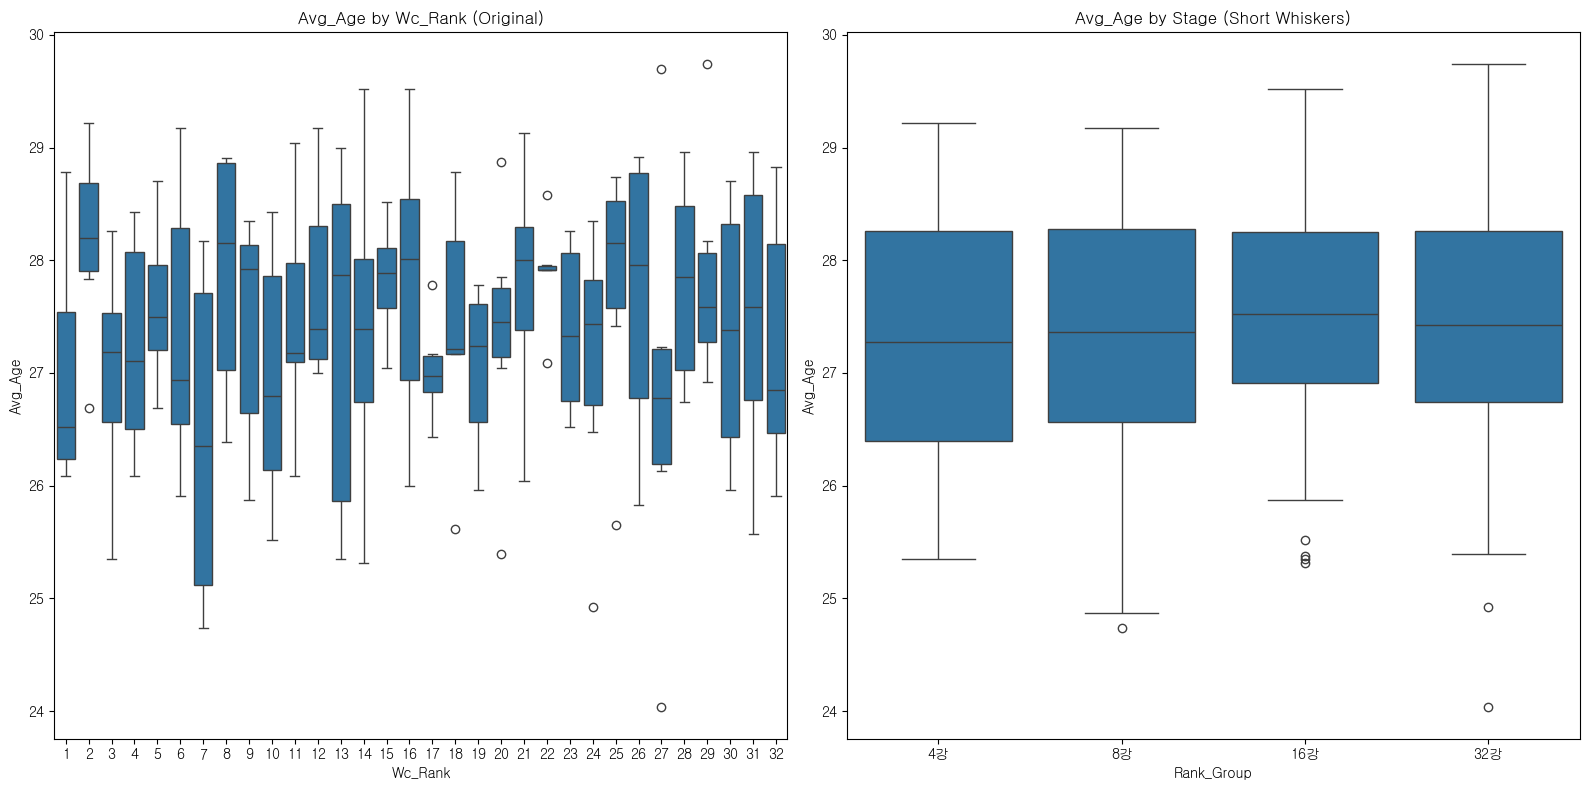

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# === 왼쪽: 원본 순위 기준 ===
sns.boxplot(x="Wc_Rank", y="Avg_Age", data=df, ax=ax[0])
ax[0].set_title("Avg_Age by Wc_Rank (Original)")

# === 오른쪽: 그룹화 + 꼬리 짧게 ===
sns.boxplot(x="Rank_Group", y="Avg_Age", data=df,
            order=["4강","8강","16강","32강"], whis=1.0, ax=ax[1])
ax[1].set_title("Avg_Age by Stage (Short Whiskers)")

plt.tight_layout()
plt.show()


<Axes: xlabel='Rank_Group', ylabel='Q_WR'>

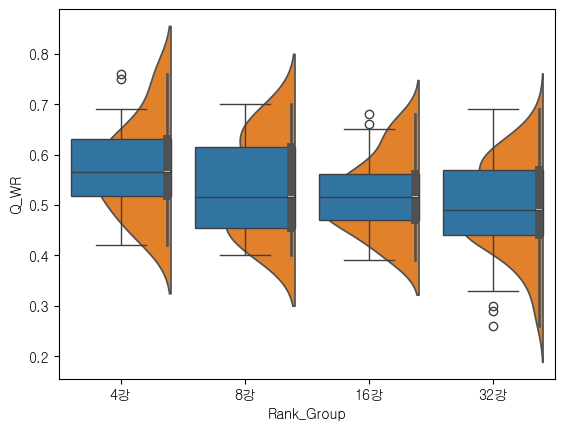

In [35]:
sns.boxplot(x="Rank_Group", y="Q_WR", data=df, whis=1.0)
sns.violinplot(x="Rank_Group", y="Q_WR", data=df, split=True)
